# 1. Load Data

In [1]:
# Global Import and Directories
import sys
sys.path.append("..")
import Setup
from Setup import *

Current working directory: /home/qusta100/STGNN/02_Code/04_Model_Calibration


# 2. Evaluating the Accuracy

In [3]:
def plot_station_from_files(
    data_path,
    pred_path,
    station_global,
    hs=(0, 1, 3),
    start_time="2025-04-01 00:00:00",
    figsize=(14, 8),
    debug_shapes=True,
    save_path=None,          # <- neu
    dpi=200,                 # <- neu
):
    # --- Laden ---
    data = torch.load(data_path, map_location="cpu")
    pred_pack = torch.load(pred_path, map_location="cpu")

    # --- True Values aus data ---
    y_true = data["y"]

    # --- Predictions robust rausziehen ---
    if isinstance(pred_pack, dict):
        print("Prediction keys:", list(pred_pack.keys()))
        y_pred = None
        for k in ["y_pred", "pred", "preds", "predictions", "out", "outputs"]:
            if k in pred_pack:
                y_pred = pred_pack[k]
                print("Using key:", k)
                break
        if y_pred is None:
            raise KeyError("Kein passender Key für Predictions gefunden.")
    else:
        y_pred = pred_pack

    targets = pred_pack["targets"]
    end_idx = pred_pack["end_idx"]
    valid_nodes = data["valid_nodes"]

    # --- Debug-Ausgaben ---
    if debug_shapes:
        print("y_true shape:", y_true.shape)
        print("y_pred shape:", y_pred.shape)
        print("same shape?", y_true.shape == y_pred.shape)
        print("targets shape:", targets.shape)
        print("valid_nodes:", type(valid_nodes), "len:", len(valid_nodes))

    # --- Station global -> local ---
    matches = np.where(valid_nodes == station_global)[0]
    if len(matches) == 0:
        raise ValueError(f"Station {station_global} ist nicht in valid_nodes.")
    station_local = int(matches[0])

    # --- Zeitachse bauen ---
    end_idx_np = end_idx.cpu().numpy() if torch.is_tensor(end_idx) else np.asarray(end_idx)
    start_time = pd.Timestamp(start_time)
    t = start_time + pd.to_timedelta(end_idx_np * 15, unit="min")

    labels = ["+15min", "+30min", "+45min", "+60min"]

    # --- Plot ---
    fig, axes = plt.subplots(len(hs), 1, figsize=figsize, sharex=True)
    if len(hs) == 1:
        axes = [axes]

    for ax, h in zip(axes, hs):
        y_s = targets[:, station_local, h].cpu().numpy()
        p_s = y_pred[:, station_local, h].cpu().numpy()

        ax.plot(t, y_s, label="true")
        ax.plot(t, p_s, label="pred")
        ax.set_title(f"Station {station_global} ({labels[h]})")
        ax.set_ylabel("price")
        ax.legend()

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m.%Y %H:%M"))
    plt.xticks(rotation=30)
    plt.tight_layout()

    # --- Speichern ---
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print("Saved plot to:", save_path)

    plt.show()
    plt.close(fig)


## 2.1. Sample: Thuringia (TH)

### 2.1.1. Fuel Type: E5

Prediction keys: ['seed', 'hyperparams', 'preds', 'targets', 'end_idx']
Using key: preds
y_true shape: torch.Size([2872, 1013, 4])
y_pred shape: torch.Size([431, 408, 4])
same shape? False
targets shape: torch.Size([431, 408, 4])
valid_nodes: <class 'numpy.ndarray'> len: 408
Saved plot to: /home/qusta100/STGNN/03_Graphs/03_Model_Evaluation /01_E5/Accuracy_Thuringia_E5_1.png


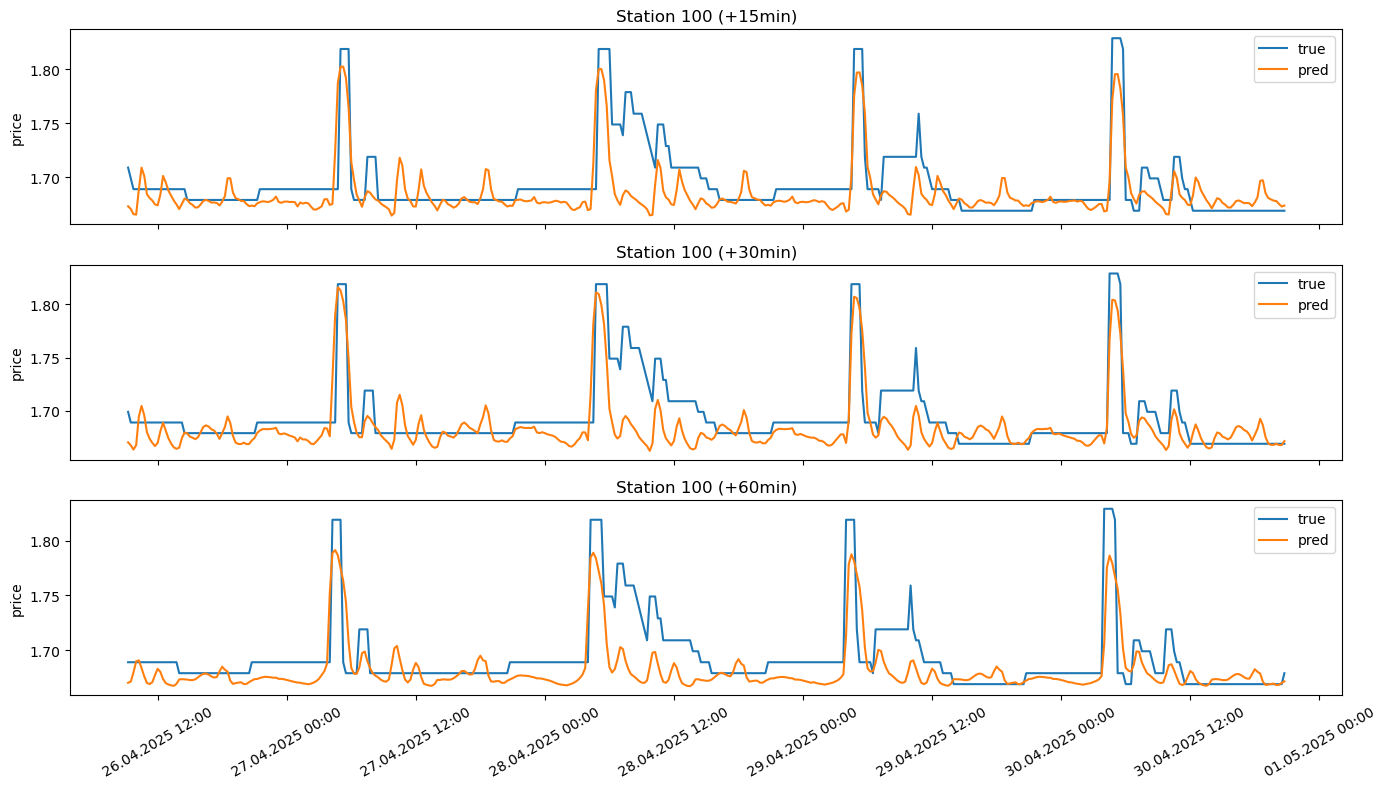

In [4]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "01_Thuringia" / "01_E5" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "01_Thuringia" / "01_E5" / "preds_test_seed42.pt",
    station_global=100,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "01_E5" / "Accuracy_Thuringia_E5_1.png"
)

Prediction keys: ['seed', 'hyperparams', 'preds', 'targets', 'end_idx']
Using key: preds
y_true shape: torch.Size([2872, 1013, 4])
y_pred shape: torch.Size([431, 408, 4])
same shape? False
targets shape: torch.Size([431, 408, 4])
valid_nodes: <class 'numpy.ndarray'> len: 408
Saved plot to: /home/qusta100/STGNN/03_Graphs/03_Model_Evaluation /01_E5/Accuracy_Thuringia_E5_2.png


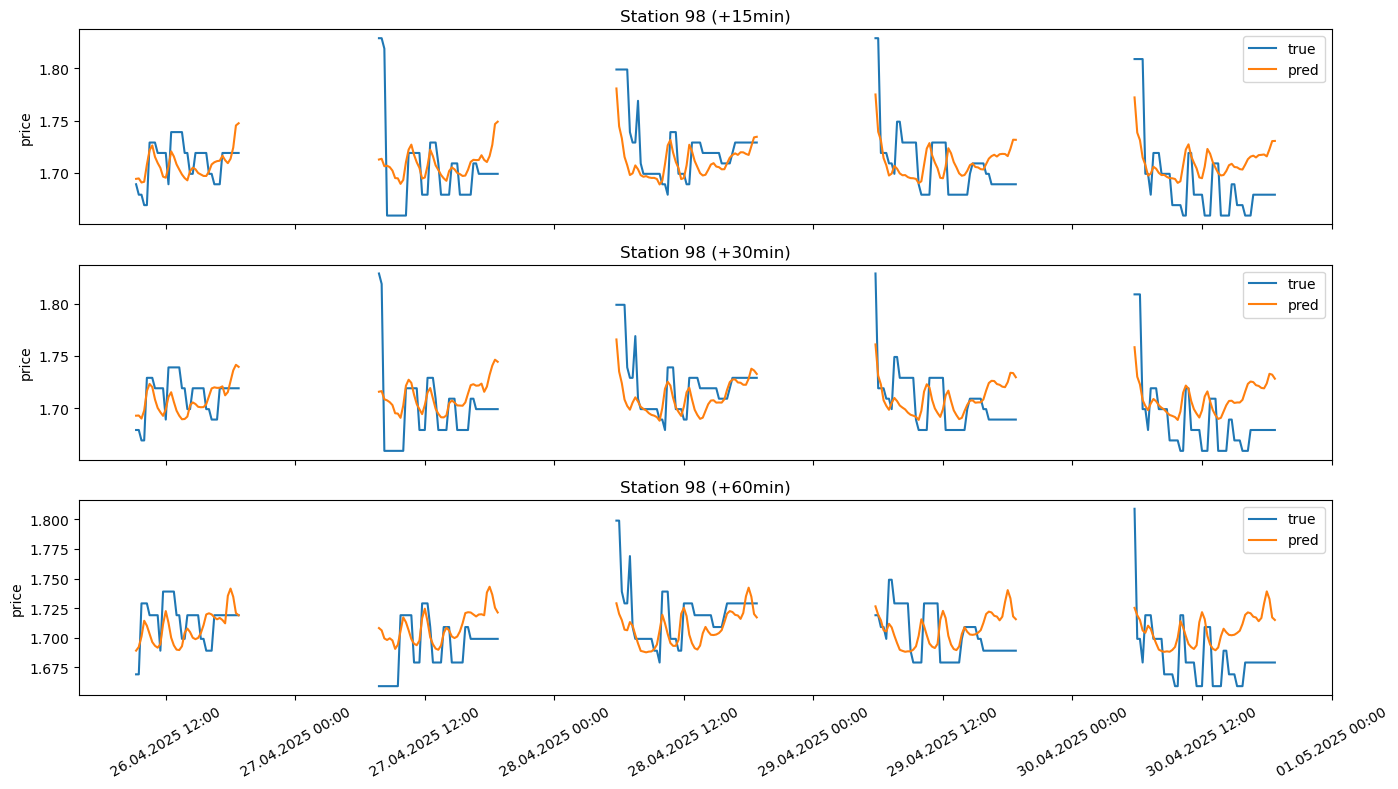

In [5]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "01_Thuringia" / "01_E5" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "01_Thuringia" / "01_E5" / "preds_test_seed42.pt",
    station_global=98,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "01_E5" / "Accuracy_Thuringia_E5_2.png"
)

### 2.1.1. Fuel Type: E10

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "01_Thuringia" / "02_E10" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "01_Thuringia" / "02_E10" / "preds_test_seed42.pt",
    station_global=100,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "02_E10" / "Accuracy_Thuringia_E10_1.png"
)

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "01_Thuringia" / "02_E10" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "01_Thuringia" / "02_E10" / "preds_test_seed42.pt",
    station_global=98,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "02_E10" / "Accuracy_Thuringia_E10_2.png"
)

### 2.1.1. FuelType: Diesel

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "01_Thuringia" / "03_Diesel" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "01_Thuringia" / "03_Diesel" / "preds_test_seed42.pt",
    station_global=100,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "03_Diesel" / "Accuracy_Thuringia_Diesel_1.png"
)

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "01_Thuringia" / "03_Diesel" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "01_Thuringia" / "03_Diesel" / "preds_test_seed42.pt",
    station_global=100,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "03_Diesel" / "Accuracy_Thuringia_Diesel_2.png"
)

## 2.1. Sample: Hesse (HE)

### 2.1.1. Fuel Type: E5

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "02_Hesse" / "01_E5" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "02_Hesse" / "01_E5" / "preds_test_seed42.pt",
    station_global=100,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "01_E5" / "Accuracy_Hesse_E5_1.png"
)

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "02_Hesse" / "01_E5" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "02_Hesse" / "01_E5" / "preds_test_seed42.pt",
    station_global=98,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "01_E5" / "Accuracy_Hesse_E5_2.png"
)

### 2.1.1. Fuel Type: E10

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "02_Hesse" / "02_E10" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "02_Hesse" / "02_E10" / "preds_test_seed42.pt",
    station_global=100,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "02_E10" / "Accuracy_Hesse_E10_1.png"
)

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "02_Hesse" / "02_E10" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "02_Hesse" / "02_E10" / "preds_test_seed42.pt",
    station_global=98,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "02_E10" / "Accuracy_Hesse_E10_2.png"
)

### 2.1.1. Fuel Type: Diesel

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "02_Hesse" / "03_Diesel" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "02_Hesse" / "03_Diesel" / "preds_test_seed42.pt",
    station_global=100,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "03_Diesel" / "Accuracy_Hesse_Diesel_1.png"
)

In [ ]:
plot_station_from_files(
    data_path=Setup.DATA_SCRATCH / "02_Processed_Data" / "03_Data_Windows" / "02_Hesse" / "03_Diesel" / "02_Time" / "data_Time_4N.pt",
    pred_path=Setup.HOME_ROOT / "04_Results" / "01_Temporary" / "05_Predictions" / "04_Model_Calibration" / "02_Hesse" / "03_Diesel" / "preds_test_seed42.pt",
    station_global=98,
    hs=(0,1,3),
    start_time="2025-04-01 00:00:00",
    debug_shapes=True,
    save_path=Setup.HOME_ROOT / "03_Graphs" / "03_Model_Evaluation "/ "03_Diesel" / "Accuracy_Hesse_Diesel_2.png"
)